In [1]:
# Databricks notebook source
# 60 TPD melter - SFC recommender: TRAINING / RETRAINING JOB (1 of 2)
#
# 1. reads the 15-min analytical record from the INPUT folder (CSV or Parquet)
# 2. cleans it with the agreed rules (NCV validity and spikes, sensor zeros, draw doubling)
# 3. builds the daily and hourly tables and keeps the usable days
# 4. trains the two recommenders:
#      gas   - daily gas-heat target  -> NG setpoint, secondary air, air-fuel ratio
#      boost - MB3 bottom-temperature controller -> barrier boost
# 5. checks the new model (signs, ranges, walk-forward calibration)
# 6. writes the model file + training report to the OUTPUT folder; the inference job
#    (02_inference_recommendation_email) reads sfc_recommender_latest.json from there.
#
# Self-contained: pandas + numpy + matplotlib only. Schedule it daily (after the SAP draw of
# the previous day is available) so the model follows the furnace.

# SFC Recommender — Training Job
**60 TPD flint melter · lines S09–S12 · melter natural gas, barrier boost, melter boost**

| | |
|---|---|
| **Reads** | `input/analytical_record_15min.csv` (or `.parquet`): the 15-min analytical record |
| **Writes** | `output/sfc_recommender_latest.json` (the model), `output/sfc_recommender_<date>.json` (versioned copy), `output/training_report_<date>.json`, `output/historical_limits.csv` |
| **Used by** | `02_inference_recommendation_email` |
| **Run** | daily, after the previous day's SAP draw is available |

**What is trained**
- **Gas recommender:** a daily **gas-heat target** = regression on all usable history (draw, barrier boost, melter boost, furnace age), shifted to the level the most efficient quarter of the last 45 days reached. Every reversal cycle: `NG = target ÷ 96 ÷ latest NCV`; `secondary air = air-per-Mcal target × gas heat`; `AFR = air ÷ NG`.
- **Barrier-boost recommender:** hourly controller on the MB3 bottom temperature, using the measured response of MB3 to boost: `boost next hour = boost last hour + 0.1 × (MB3 target − MB3 now) ÷ gain`.
- **Historical limits** (P1–P99 of the furnace's own history): every recommendation is kept inside them.

In [2]:
import json
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:                                   # Databricks
    displayHTML                        # noqa: B018
except NameError:                      # local Jupyter
    from IPython.display import HTML, display
    def displayHTML(html):             # noqa: N802
        display(HTML(html))

## 1. Settings
Everything the job needs is in this cell. In Databricks, point `INPUT_DIR` / `OUTPUT_DIR` at the Volume or workspace folder (examples in the comments). The widget lines are kept commented so the notebook can become a scheduled job without edits.

In [3]:
# dbutils.widgets.text("input_dir",  "/Volumes/prod_pgp_mfg/cantier/60_tpd_sfc/input")
# dbutils.widgets.text("output_dir", "/Volumes/prod_pgp_mfg/cantier/60_tpd_sfc/output")
# INPUT_DIR, OUTPUT_DIR = Path(dbutils.widgets.get("input_dir")), Path(dbutils.widgets.get("output_dir"))

# ---- folders and files ---------------------------------------------------------------------
INPUT_DIR = Path("input")                       # e.g. Path("/Volumes/prod_pgp_mfg/cantier/60_tpd_sfc/input")
OUTPUT_DIR = Path("output")                     # e.g. Path("/Volumes/prod_pgp_mfg/cantier/60_tpd_sfc/output")
INPUT_FILE = "analytical_record_15min.csv"      # .csv or .parquet, columns as in the analytical record
MODEL_NAME = "sfc_recommender"

# ---- project constants (agreed with the plant; do not change without a review) ------------
KCAL_PER_KWH = 860
AGE_ORIGIN = pd.Timestamp("2025-09-01")         # furnace-age clock for the ageing term
BASELINE_START, BASELINE_END = "2025-09-01", "2026-07-31"   # client baseline period (M&V, frozen)
CLIENT_BASELINE_SFC, CLIENT_TARGET_SFC = 1576.3, 1544.8

# ---- cleaning rules -------------------------------------------------------------------------
VALID_RANGE = {                                 # outside -> sensor fault / typing error -> missing
    "ncv": (8500, 10500), "opt_temp": (1550, 1600), "mb_kwh": (1, 200), "bb_kwh": (1, 250)}
NCV_SPIKE = 400                                 # kcal/SCM away from the ~2 h median -> glitch
DRAW_DOUBLED = 1.6                              # draw > 1.6 x surrounding-week median -> halved
MIN_COVERAGE = 0.90                             # a usable day needs >= 90% valid NCV, gas and boost

# ---- model settings (chosen in the model-selection study) -----------------------------------
GAS_FEATURES = ["draw_t", "bb_g", "mb_g", "age_m"]
SHIFT_WINDOW_DAYS, SHIFT_QUANTILE = 45, 0.25    # target = efficient quarter of the last 45 days
AIR_QUANTILE, AIR_FLOOR_QUANTILE = 0.25, 0.05
STEP_LAGS, KI = 12, 0.1                         # MB3 response horizon (h), controller speed
LIMIT_Q = (0.01, 0.99)                          # historical limits = P1-P99

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("input :", INPUT_DIR / INPUT_FILE)
print("output:", OUTPUT_DIR)

input : input/analytical_record_15min.csv
output: output


## 2. Load the data
The analytical record with its original column names. The column map below is the only place that knows them; if the source table uses other names, change the left-hand side only.

In [4]:
COLUMNS = {
    "Timestamps": "ts",
    "BARRIER BOOSTER-52": "bb_kwh",                                   # kWh per 15 min
    "MELTER BOOSTER-51": "mb_kwh",                                    # kWh per 15 min
    "NCV Meter": "ncv",                                               # kcal/SCM
    "Cullet %": "cullet_pct",
    "Melter Optical Temperature": "opt_temp",                         # deg C (hourly, typed)
    "dcs_60_SecondaryAirFlowvalueFTSAFPVDB205DD92": "sec_air",        # per 15 min, operator unit
    "dcs_60_MelterGasflowvalueFTMGFPVDB202DD92": "ng_scm",            # per 15 min, operator unit
    "dcs_60_ThermocoupleMelterBottom3TCMB3PVDB249DD572": "mb3_temp",  # deg C
    "Seed Count": "seed_count",
    "Daily Draw": "draw_kg",                                          # SAP daily draw, kg
    "MB51_Quantity_KG (Draw)": "draw_kg",
}
NUMERIC = ["bb_kwh", "mb_kwh", "ncv", "cullet_pct", "opt_temp", "sec_air", "ng_scm", "mb3_temp", "seed_count", "draw_kg"]


def read_table(path: Path) -> pd.DataFrame:
    """CSV or Parquet. In Databricks a Spark read works too:
    spark.read.option("header", "true").csv(str(path)).toPandas()"""
    return pd.read_parquet(path) if str(path).lower().endswith(".parquet") else pd.read_csv(path)


raw = read_table(INPUT_DIR / INPUT_FILE).rename(columns=COLUMNS)
missing = [c for c in ["ts"] + NUMERIC if c not in raw.columns]
if missing:
    raise ValueError(f"input is missing columns: {missing}")
raw["ts"] = pd.to_datetime(raw["ts"])
for c in NUMERIC:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
print(f"{len(raw):,} rows | {raw.ts.min():%d %b %Y %H:%M} to {raw.ts.max():%d %b %Y %H:%M}")
raw[["ts"] + NUMERIC].head()

37,920 rows | 01 Sep 2025 00:00 to 30 Sep 2026 23:45


,ts,bb_kwh,mb_kwh,ncv,cullet_pct,opt_temp,sec_air,ng_scm,mb3_temp,seed_count,draw_kg
0,2025-09-01 00:00:00,147.0,57.2,0.0,20,NaN,906.713340,86.194461,1324.369179,11,60554
1,2025-09-01 00:15:00,142.0,57.2,0.0,20,NaN,906.657798,80.856787,1324.475854,11,60554
2,2025-09-01 00:30:00,142.0,57.2,0.0,20,NaN,906.128664,80.790584,1324.735849,11,60554
3,2025-09-01 00:45:00,143.0,57.2,0.0,20,NaN,906.624808,80.878856,1325.029184,11,60554
4,2025-09-01 01:00:00,143.0,57.2,0.0,20,NaN,905.924262,86.263423,1325.169229,11,60554


## 3. Clean the 15-minute data
| Rule | Why |
|---|---|
| one row per timestamp | duplicated rows are averaged |
| NCV kept only between 8,500 and 10,500 kcal/SCM | 0 = meter not working; real gas stays inside this range |
| NCV more than 400 away from the ~2 h median → missing | meter spikes |
| boosts and optical outside their plausible range → missing | dead sensors, typing errors |
| daily draw > 1.6 × the surrounding week → halved | two SAP entries added together on some month-start days |
| gas heat = Σ NG × NCV per 15 min | the client's SFC formula, never daily NG × average NCV |

In [5]:
def clean_15min(raw: pd.DataFrame) -> pd.DataFrame:
    q = raw.groupby("ts")[NUMERIC].mean().sort_index()
    for col, (lo, hi) in VALID_RANGE.items():
        q.loc[q[col].notna() & ~q[col].between(lo, hi), col] = np.nan
    med = q["ncv"].rolling(9, center=True, min_periods=3).median()
    q.loc[(q["ncv"] - med).abs() > NCV_SPIKE, "ncv"] = np.nan
    day_draw = q["draw_kg"].groupby(q.index.normalize()).first()
    week_med = day_draw.rolling(7, center=True, min_periods=3).median()
    doubled = day_draw > DRAW_DOUBLED * week_med
    fixed = pd.Series(np.where(doubled, day_draw / 2, day_draw), index=day_draw.index)
    q["draw_fixed"] = doubled.reindex(q.index.normalize()).to_numpy()
    q["draw_kg"] = fixed.reindex(q.index.normalize()).to_numpy()
    q["afr"] = q["sec_air"] / q["ng_scm"]
    q["gas_kcal"] = q["ng_scm"] * q["ncv"]
    q.index.name = "ts"
    return q


q = clean_15min(raw)
fixed_days = sorted({t.date() for t in q.index[q["draw_fixed"].fillna(False).astype(bool)]})
print("NCV readings kept: %.1f%% | draw halved on: %s" % (100 * q.ncv.notna().mean(), ", ".join(map(str, fixed_days)) or "none"))

NCV readings kept: 88.7% | draw halved on: 2025-10-01, 2026-06-01, 2026-09-01


## 4. Daily and hourly tables

usable days: 343 of 395 (11 Oct 2025 to 29 Sep 2026) | baseline period: 286 | baseline SFC (our data): 1576.6 kcal/kg


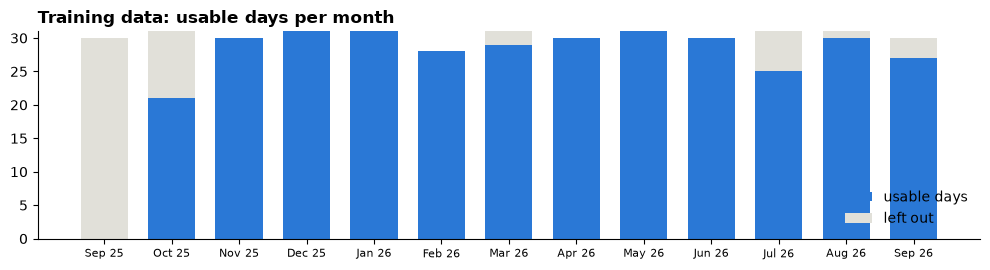

In [6]:
def build_daily(q: pd.DataFrame) -> pd.DataFrame:
    f = q.copy()
    for col in ["ng_scm", "bb_kwh", "mb_kwh", "sec_air"]:
        f[col] = f[col].interpolate(limit=4, limit_area="inside")          # gaps <= 1 h only
    f["date"] = f.index.normalize()
    g = f.groupby("date")
    d = pd.DataFrame({
        "ng_scm": g["ng_scm"].sum(min_count=1), "sec_air": g["sec_air"].sum(min_count=1),
        "ng_cov": g["ng_scm"].apply(lambda s: s.notna().mean()), "ncv_cov": g["ncv"].apply(lambda s: s.notna().mean()),
        "bb_kwh": g["bb_kwh"].sum(min_count=1), "mb_kwh": g["mb_kwh"].sum(min_count=1),
        "boost_cov": g["bb_kwh"].apply(lambda s: s.notna().mean()),
        "draw_kg": g["draw_kg"].first(), "cullet_pct": g["cullet_pct"].first(), "seed_count": g["seed_count"].first(),
        "opt_temp": g["opt_temp"].mean(), "mb3_temp": g["mb3_temp"].mean()})
    both = f.dropna(subset=["ng_scm", "ncv"])
    d["ncv"] = (both["ng_scm"] * both["ncv"]).groupby(both["date"]).sum() / both.groupby("date")["ng_scm"].sum()
    d["gas_kcal"] = d["ng_scm"] * d["ncv"]
    d["energy_kcal"] = d["gas_kcal"] + (d["bb_kwh"] + d["mb_kwh"]) * KCAL_PER_KWH
    d["sfc"] = d["energy_kcal"] / d["draw_kg"]
    d["air_per_mcal"] = d["sec_air"] / (d["gas_kcal"] / 1000)
    d["draw_t"] = d["draw_kg"] / 1000
    d["usable"] = (d["ncv_cov"] >= MIN_COVERAGE) & (d["ng_cov"] >= MIN_COVERAGE) & (d["boost_cov"] >= MIN_COVERAGE) & d["draw_kg"].notna()
    d["in_baseline"] = (d.index >= BASELINE_START) & (d.index <= BASELINE_END)
    d.index.name = "date"
    return d


def build_hourly(q: pd.DataFrame) -> pd.DataFrame:
    r = q.resample("h")
    h = pd.DataFrame({"gas_kcal": r["gas_kcal"].sum(min_count=4), "bb_kwh": r["bb_kwh"].sum(min_count=4),
                      "mb_kwh": r["mb_kwh"].sum(min_count=4), "mb3_temp": r["mb3_temp"].mean()})
    h.index.name = "ts"
    return h


d, h = build_daily(q), build_hourly(q)
u = d[d.usable].copy()
u["gas_g"] = u["gas_kcal"] / 1e6
u["bb_g"] = u["bb_kwh"] * KCAL_PER_KWH / 1e6
u["mb_g"] = u["mb_kwh"] * KCAL_PER_KWH / 1e6
u["age_m"] = (u.index - AGE_ORIGIN).days / 30.44
u = u.dropna(subset=GAS_FEATURES + ["gas_g"])
print(f"usable days: {len(u)} of {len(d)} ({u.index.min():%d %b %Y} to {u.index.max():%d %b %Y}) | "
      f"baseline period: {int(u.in_baseline.sum())} | baseline SFC (our data): {u[u.in_baseline].sfc.mean():.1f} kcal/kg")

m = d.groupby(d.index.to_period("M")).agg(usable=("usable", "sum"), days=("usable", "size"))
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.bar(range(len(m)), m.usable, color="#2a78d6", width=0.7, label="usable days")
ax.bar(range(len(m)), m.days - m.usable, bottom=m.usable, color="#e1e0d9", width=0.7, label="left out")
ax.set_xticks(range(len(m))); ax.set_xticklabels([p.strftime("%b %y") for p in m.index], fontsize=8)
ax.set_title("Training data: usable days per month", loc="left", fontweight="bold"); ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()

## 5. Train the gas recommender
`gas heat (Gcal/day) = a + b·draw + c·barrier boost + d·melter boost + e·furnace age`, fitted on all usable days, then shifted so that only the most efficient 25% of the last 45 days beat it.

In [7]:
def ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    A = np.column_stack([np.ones(len(X)), X])
    return np.linalg.lstsq(A, y, rcond=None)[0]


def predict(beta: np.ndarray, X: np.ndarray) -> np.ndarray:
    return beta[0] + X @ beta[1:]


beta = ols(u[GAS_FEATURES].to_numpy(), u["gas_g"].to_numpy())
trained_until = u.index.max()
recent = u[u.index > trained_until - pd.Timedelta(days=SHIFT_WINDOW_DAYS)]
shift = float(np.quantile(recent["gas_g"] - predict(beta, recent[GAS_FEATURES].to_numpy()), SHIFT_QUANTILE))
gas_coefficients = dict(zip(["Intercept"] + GAS_FEATURES, map(float, beta)))

pd.DataFrame({"coefficient": gas_coefficients,
              "meaning": {"Intercept": "base level (Gcal/day)", "draw_t": "Gcal/day per +1 t/day draw",
                          "bb_g": "Gcal gas per Gcal barrier boost", "mb_g": "Gcal gas per Gcal melter boost",
                          "age_m": "Gcal/day per month of furnace age"}}).round(4)

,coefficient,meaning
Intercept,52.1949,base level (Gcal/day)
draw_t,0.4953,Gcal/day per +1 t/day draw
bb_g,-0.7715,Gcal gas per Gcal barrier boost
mb_g,-0.0993,Gcal gas per Gcal melter boost
age_m,0.3498,Gcal/day per month of furnace age


In [8]:
print(f"efficient-quarter shift: {shift:+.3f} Gcal/day (from the last {SHIFT_WINDOW_DAYS} days)")
apm = u["air_per_mcal"].dropna()
air_per_mcal = float(max(apm[apm.index > trained_until - pd.Timedelta(days=SHIFT_WINDOW_DAYS)].quantile(AIR_QUANTILE),
                         apm.quantile(AIR_FLOOR_QUANTILE)))
print(f"air-per-Mcal target: {air_per_mcal:.4f} SCM/Mcal (P25 of the last {SHIFT_WINDOW_DAYS} days, floor = historical P5)")

efficient-quarter shift: -0.412 Gcal/day (from the last 45 days)
air-per-Mcal target: 1.2676 SCM/Mcal (P25 of the last 45 days, floor = historical P5)


## 6. Train the barrier-boost recommender
The MB3 response to a lasting +1 kWh/h of barrier boost is measured from the hourly history with a distributed-lag model (MB3 change vs boost and gas changes of the previous 0–12 h). The early dip caused by operator reactions is removed.

MB3 gain: 1.94 degC per +100 kWh/h (6,736 hours) | MB3 target (historical median): 1320.25 degC


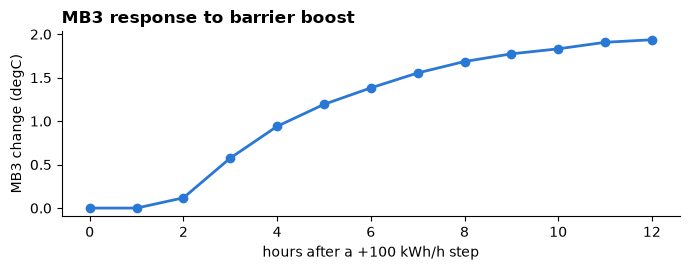

In [9]:
x = h[["mb3_temp", "bb_kwh", "gas_kcal"]].dropna().asfreq("h")
lag = pd.DataFrame({"dmb3": x["mb3_temp"].diff()})
for k in range(STEP_LAGS + 1):
    lag[f"dbb{k}"] = x["bb_kwh"].diff().shift(k)
    lag[f"dgas{k}"] = (x["gas_kcal"] / 1e6).diff().shift(k)
lag = lag.dropna()
cols = [c for c in lag.columns if c != "dmb3"]
coef = pd.Series(ols(lag[cols].to_numpy(), lag["dmb3"].to_numpy())[1:], index=cols)
step = coef[[f"dbb{k}" for k in range(STEP_LAGS + 1)]].cumsum().clip(lower=0).cummax().reset_index(drop=True)
mb3_gain = float(step.iloc[-1])
mb3_target = float(h["mb3_temp"].median())
print(f"MB3 gain: {mb3_gain * 100:.2f} degC per +100 kWh/h ({len(lag):,} hours) | MB3 target (historical median): {mb3_target:.2f} degC")

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(step.index, step * 100, color="#2a78d6", marker="o", lw=2)
ax.set_xlabel("hours after a +100 kWh/h step"); ax.set_ylabel("MB3 change (degC)")
ax.set_title("MB3 response to barrier boost", loc="left", fontweight="bold"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Historical limits (P1–P99) and the M&V yardsticks

In [10]:
lo, hi = LIMIT_Q
limits = {
    "ng_scm":       [q["ng_scm"].quantile(lo), q["ng_scm"].quantile(hi)],
    "afr":          [q["afr"].quantile(lo), q["afr"].quantile(hi)],
    "bb_kwh_h":     [h["bb_kwh"].quantile(lo), h["bb_kwh"].quantile(hi)],
    "mb3_temp":     [h["mb3_temp"].quantile(lo), h["mb3_temp"].quantile(hi)],
    "opt_temp":     [q["opt_temp"].quantile(lo), q["opt_temp"].quantile(hi)],
    "ncv":          [float(VALID_RANGE["ncv"][0]), float(VALID_RANGE["ncv"][1])],
    "draw_t":       [u["draw_t"].quantile(lo), u["draw_t"].quantile(hi)],
    "sec_air":      [q["sec_air"].quantile(lo), q["sec_air"].quantile(hi)],
    "gas_day_gcal": [u["gas_g"].quantile(lo), u["gas_g"].quantile(hi)],
}
limits = {k: [float(a), float(b)] for k, (a, b) in limits.items()}
LIMIT_LABELS = {"ng_scm": "NG setpoint (per 15 min)", "afr": "Air-fuel ratio", "bb_kwh_h": "Barrier boost (kWh/h)",
                "mb3_temp": "MB3 bottom temperature (degC)", "opt_temp": "Optical crown temperature (degC)",
                "ncv": "NCV accepted (kcal/SCM)", "draw_t": "Draw (t/day)", "sec_air": "Secondary air (per 15 min)",
                "gas_day_gcal": "Daily gas heat (Gcal/day, flag only)"}
lim_table = pd.DataFrame(limits, index=["lower limit (P1)", "upper limit (P99)"]).T
lim_table.insert(0, "item", [LIMIT_LABELS[k] for k in lim_table.index])

# M&V yardsticks: fitted on the fixed baseline period, so they never move on retraining
base = u[u.in_baseline]
mA = ols(base[["draw_t", "cullet_pct"]].to_numpy(), (base["energy_kcal"] / 1e6).to_numpy())
model_a = {"Intercept": float(mA[0]), "draw_t": float(mA[1]), "cullet_pct": float(mA[2])}
bands = pd.cut(base["draw_t"], [45, 50, 55, 60, 65], labels=["45-50", "50-55", "55-60", "60-65"], include_lowest=True)
band_baseline = {str(k): float(v) for k, v in base.groupby(bands, observed=True)["sfc"].mean().items()}
print("draw-adjusted yardstick: E = %.2f + %.3f x draw + %.3f x cullet (Gcal/day)" % tuple(model_a.values()))
lim_table.round(2)

draw-adjusted yardstick: E = 53.55 + 0.605 x draw + 0.123 x cullet (Gcal/day)


,item,lower limit (P1),upper limit (P99)
ng_scm,NG setpoint (per 15 min),73.86,96.34
afr,Air-fuel ratio,10.99,13.44
bb_kwh_h,Barrier boost (kWh/h),114.30,609.80
mb3_temp,MB3 bottom temperature (degC),1316.14,1325.51
opt_temp,Optical crown temperature (degC),1568.00,1578.00
ncv,NCV accepted (kcal/SCM),8500.00,10500.00
draw_t,Draw (t/day),49.10,62.22
sec_air,Secondary air (per 15 min),920.51,1104.22
gas_day_gcal,"Daily gas heat (Gcal/day, flag only)",72.54,80.90


## 8. Checks before the model is released
- **Signs and ranges:** the coefficients must make physical sense.
- **Walk-forward calibration:** for each of the last 30 usable days, the target is rebuilt from earlier days only. About 25% of days should already beat it.

If any check fails, `sfc_recommender_latest.json` is **not** replaced, and the inference job keeps using the previous model.

ALL CHECKS PASSED


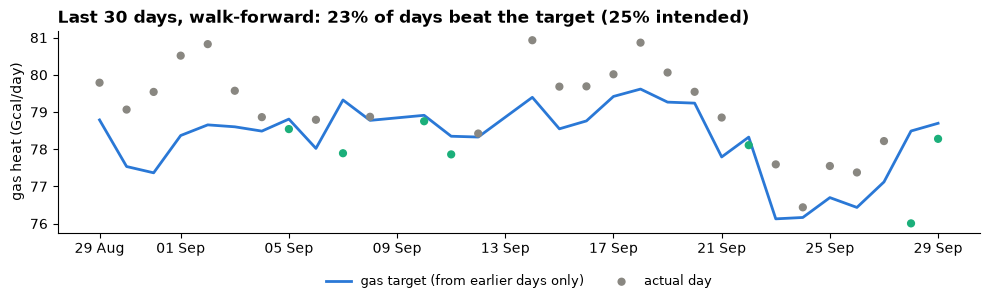

,check,value,result
0,usable training days >= 200,343.0000,PASS
1,draw coefficient > 0,0.4953,PASS
2,barrier-boost coefficient between -1.2 and -0.3,-0.7715,PASS
3,ageing coefficient >= 0,0.3498,PASS
4,MB3 gain 0.010-0.030 degC per kWh/h,0.0194,PASS
5,air per Mcal 1.15-1.40,1.2676,PASS
6,last 30 days: share beating the target 10-45%,0.2333,PASS


In [11]:
def walk_forward_target(day) -> float:
    hist = u[u.index < day]
    b = ols(hist[GAS_FEATURES].to_numpy(), hist["gas_g"].to_numpy())
    rec = hist[hist.index >= day - pd.Timedelta(days=SHIFT_WINDOW_DAYS)]
    s = np.quantile(rec["gas_g"] - predict(b, rec[GAS_FEATURES].to_numpy()), SHIFT_QUANTILE)
    return float(predict(b, u.loc[[day], GAS_FEATURES].to_numpy())[0] + s)


check_days = u.index[-30:]
wf = pd.DataFrame({"actual": u.loc[check_days, "gas_g"], "target": [walk_forward_target(t) for t in check_days]})
coverage = float((wf.actual <= wf.target).mean())

checks = {
    "usable training days >= 200":                        (len(u), len(u) >= 200),
    "draw coefficient > 0":                               (beta[1], beta[1] > 0),
    "barrier-boost coefficient between -1.2 and -0.3":    (beta[2], -1.2 < beta[2] < -0.3),
    "ageing coefficient >= 0":                            (beta[4], beta[4] >= 0),
    "MB3 gain 0.010-0.030 degC per kWh/h":                (mb3_gain, 0.010 < mb3_gain < 0.030),
    "air per Mcal 1.15-1.40":                             (air_per_mcal, 1.15 < air_per_mcal < 1.40),
    "last 30 days: share beating the target 10-45%":      (coverage, 0.10 <= coverage <= 0.45),
}
check_table = pd.DataFrame([{"check": k, "value": round(float(v), 4), "result": "PASS" if ok else "FAIL"} for k, (v, ok) in checks.items()])
passed = bool(all(ok for _, ok in checks.values()))
print("ALL CHECKS PASSED" if passed else "CHECK FAILED - the latest model will NOT be replaced")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(wf.index, wf.target, color="#2a78d6", lw=2, label="gas target (from earlier days only)")
ax.scatter(wf.index, wf.actual, color=np.where(wf.actual <= wf.target, "#1baf7a", "#898781"), s=24, zorder=3, label="actual day")
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_ylabel("gas heat (Gcal/day)"); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=9)
ax.set_title(f"Last 30 days, walk-forward: {coverage:.0%} of days beat the target (25% intended)", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()
check_table

## 9. Save the model to the output folder
The model is a small JSON file holding only numbers (coefficients, targets, limits). No ML library is needed to use it. The same file can be served by the backend API (`service/app.py`, `FinalRecommender.load`).

In [12]:
created = dt.datetime.now()
tag = f"{trained_until:%Y-%m-%d}"
model = {
    "schema": 1,
    "model_name": MODEL_NAME,
    "model_version": f"{tag}_{created:%Y%m%d%H%M}",
    "created_at": created.isoformat(timespec="seconds"),
    "trained_until": tag,
    "n_training_days": int(len(u)),
    "data": {"input_file": INPUT_FILE, "rows": int(len(raw)), "from": str(raw.ts.min()), "to": str(raw.ts.max())},
    "gas": {"formula": "gas_g ~ draw_t + bb_g + mb_g + age_m", "coefficients": gas_coefficients, "conformal_shift": shift,
            "age_origin": str(AGE_ORIGIN.date()), "days_per_month": 30.44, "intervals_per_day": 96, "kcal_per_kwh": KCAL_PER_KWH},
    "air": {"air_per_mcal": air_per_mcal},
    "boost": {"mb3_target": mb3_target, "mb3_gain_degC_per_kwh_h": mb3_gain, "ki": KI},
    "limits": limits,
    "mv": {"model_a": model_a, "band_baseline_sfc": band_baseline,
           "client_baseline_sfc": CLIENT_BASELINE_SFC, "client_target_sfc": CLIENT_TARGET_SFC},
}
report = {"model_version": model["model_version"], "trained_until": tag, "passed": passed,
          "checks": check_table.to_dict("records"), "walk_forward_coverage_last_30_days": coverage}

versioned = OUTPUT_DIR / f"{MODEL_NAME}_{tag}.json"
versioned.write_text(json.dumps(model, indent=2))
(OUTPUT_DIR / f"training_report_{tag}.json").write_text(json.dumps(report, indent=2))
lim_table.to_csv(OUTPUT_DIR / "historical_limits.csv")
if passed:
    (OUTPUT_DIR / f"{MODEL_NAME}_latest.json").write_text(json.dumps(model, indent=2))
    print("released ->", OUTPUT_DIR / f"{MODEL_NAME}_latest.json")
else:
    print("not released: the previous", OUTPUT_DIR / f"{MODEL_NAME}_latest.json", "stays in use")
print("saved    ->", versioned)
sorted(p.name for p in OUTPUT_DIR.iterdir())

released -> output/sfc_recommender_latest.json
saved    -> output/sfc_recommender_2026-09-29.json


['historical_limits.csv',
 'sfc_recommender_2026-09-29.json',
 'sfc_recommender_latest.json',
 'training_report_2026-09-29.json']

### Optional: also log the run to MLflow
The output folder is enough for the inference job. To keep a run history in Databricks, set `LOG_TO_MLFLOW = True`. It logs the model file and the checks as artifacts and metrics of an MLflow run.

In [13]:
LOG_TO_MLFLOW = False
if LOG_TO_MLFLOW:
    import mlflow
    with mlflow.start_run(run_name=f"{MODEL_NAME}_{tag}"):
        mlflow.log_params({"trained_until": tag, "n_training_days": len(u), "shift_window_days": SHIFT_WINDOW_DAYS})
        mlflow.log_metrics({"coverage_last_30d": coverage, "mb3_gain": mb3_gain, "air_per_mcal": air_per_mcal,
                            **{f"coef_{k}": v for k, v in gas_coefficients.items()}})
        mlflow.log_artifact(str(versioned)); mlflow.log_artifact(str(OUTPUT_DIR / f"training_report_{tag}.json"))
    print("logged to MLflow")